### Imports

In [1]:
import sys
sys.path.append('../src')

In [2]:
from eval import Eval

In [3]:
from constants import INPT_VARS, EXTRA_VARS, OUT_VARS, REGIONS
import hydra
from hydra.utils import instantiate
from pathlib import Path
import os
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt

from utils.data_utils import (
    get_wet_mask,
    get_train_test_ranges,
    gen_data_in_test,
    gen_data_out_test,
    data_CNN_Lateral,
    data_CNN_Dynamic,
    gen_data_025_lateral,
    gen_data_global_new,
)
from utils.eval_utils import (
    generate_model_rollout,
    compute_mean,
    compute_var,
    compute_corrs_area,
    compute_rmse,
    compute_corrs,
    compute_KE,
    compute_time_spec,
    compute_ACC,
    gen_KE_spectrum,
    gen_KE,
    gen_KE_range,
    gen_enstrophy_spectrum,
    gen_enstrophy,
    compute_corrs_single,
    compute_ACC_single,
    compute_RMSE_single,
)
from utils.subgrid_utils import get_area_tensor
from utils.climate_utils import compute_laplacian_wet
from utils.plot_utils import (
    plot_short_time_stats,
    plot_long_time_stats,
    plot_long_KE,
    plot_long_MSE_KE,
    plot_metrics_KE_spectrum,
    plot_metrics_KE,
    plot_metrics_enstrophy_spectrum,
    plot_metrics_entrophy,
    plot_metrics_corr,
    plot_metrics_rmse,
    plot_metrics_acc,
    plot_metrics_pdf,
    get_initial_snapshot_fig,
)

import numpy as np
import torch
import xarray as xr
import copy

### Initialization of Configs with Omegaconf and Hydra

In [4]:
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
from datetime import datetime

with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    # Basic UNet G1, G1
    cfg = compose(config_name="exp/eval_unet_global", overrides=[
        "output_dir=./temp/{0}".format(str(datetime.now())[:10]),
        "model_name_replace=Basic UNet",
        "network=Basic UNet",
        "train_region=global_1",
        "region=global_1",
        "unet.encoder.n_channels=[64,128,256,512]",
        "unet.encoder.n_layers=[2,2,2,2]",
        "unet.encoder.dilations=[1,1,1,1]",
        "unet.decoder.n_channels=[512,256,128,64]",
        "unet.decoder.n_layers=[2,2,2,2]",
        "unet.decoder.dilations=[1,1,1,1]",
        "exp/unet/modules/blocks@unet.decoder.up_sampling_block=bilinear_upsample",
        "ckpt_path=/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-07-train_basicunet_global_1/basic/saved_nets/unet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt"
    ])

import os
if not os.path.exists(cfg.output_dir):
    os.mkdir(cfg.output_dir)

#### Evaluation Modes

In [5]:
cfg.save_test_data = False # Set to False
cfg.save_clim_data = False # Set to False
cfg.run_gen_pred = False # Set to False
cfg.run_gen_short_pred = False # Set to False

cfg.run_full_pred = False
cfg.run_short_pred = False
cfg.run_plot_metrics = True
cfg.run_long_metrics = True
cfg.run_plot_animation = False

#### Instantiate Eval class

In [6]:
eval = Eval(cfg)
eval.JUPYTER_MODE = True

inputs: u_v_T_
extra inputs: tau_u_tau_v_t_ref_
outputs: u_v_T_
Number of inputs:  6
Number of outputs:  3
Getting inputs


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1035: UserWarning: rename 'lat' to 'yt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1035: UserWarning: rename 'lon' to 'xt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})


Calculating mask tensors
Wet resolution: torch.Size([180, 360])
Loading train data to save statistics
Loading test data
Loading model unet
Using absolute predictions
Loading clim
Computing area tensor


### Generate Predictions

In [7]:
if cfg.run_gen_pred:
    eval.generate_pred_lateral()
else:
    print("Skipping pred generation")

if cfg.run_gen_short_pred:
    eval.generate_short_pred_lateral()
else:
    print("Skipping short pred generation")

Skipping pred generation
Skipping short pred generation


### Generate Plots from Predictions

In [17]:
eval.send_data_to_cpu()

#### Long term prediction

In [18]:
if cfg.run_full_pred:
    eval.compare_pred_lateral()

#### Short Term Predictions

In [19]:
if cfg.run_short_pred:
    eval.compare_short_pred_lateral()

#### Metrics

##### Read

In [22]:
model_pred_net = None
model_pred_net = (
    xr.open_zarr(
        eval.pred_model_path
        / (
            "Pred_Short_Data_025_"
            + eval.post_pred_name
            + "_rand_seed_"
            + str(1)
            + ".zarr"
        )
    )
    .to_array()
    .to_numpy()
    .squeeze()
)

model_pred_saved_nets = []
for model_pred_path in eval.pred_paths:
    net_path = Path(model_pred_path) / (
        "Pred_Short_Data_025_"
        + eval.pred_region
        + "_in_"
        + eval.str_in
        + "ext_"
        + "tau_u_tau_v_t_ref_"
        + "N_samples_"
        + str(4000)
        + "_rand_seed_"
        + str(1)
        + ".zarr"
    )

    model_pred_saved_nets.append(
        xr.open_zarr(net_path).to_array().to_numpy().squeeze()
    )

### KE PDF

Getting PDF stats...
torch.Size([4236900])
torch.Size([4236900])
torch.Size([4236900])
(4236900,)
Plotting pdf...


/state/partition1/job-46339814/ipykernel_1611792/1051334038.py:29: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(


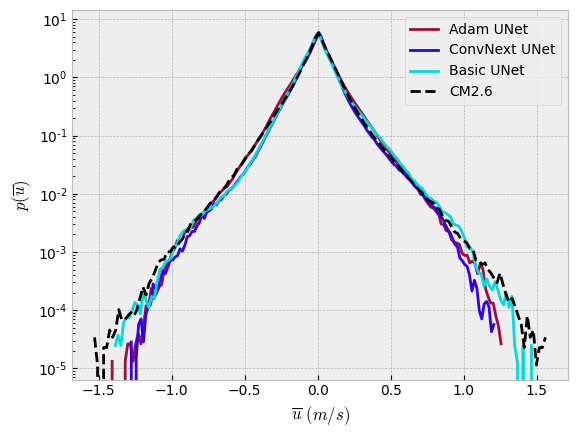

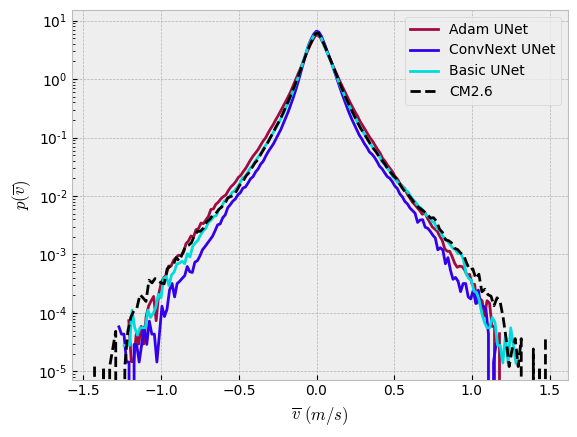

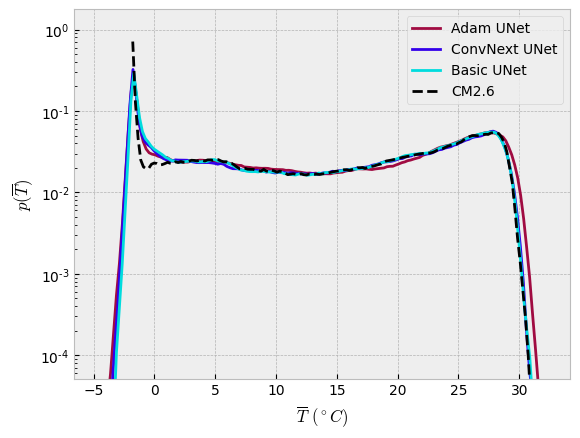

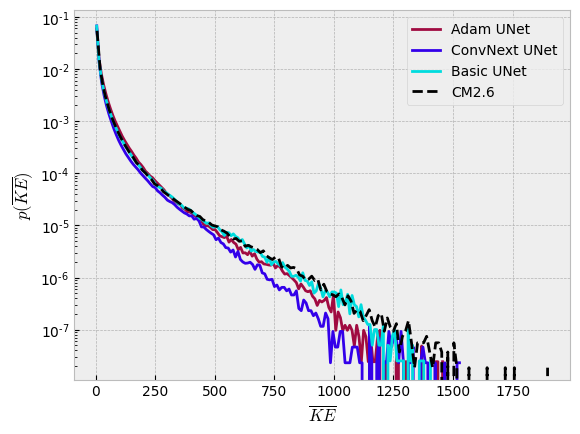

In [30]:
print("Getting PDF stats...")
N_days = 100
day_start = 100  # Last 100 days
pdf = {}

for ind_plot in range(3):
    true_field = (
        eval.test_data[day_start : day_start + N_days][1][
            :, ind_plot, eval.wet_bool
        ].flatten()
        * eval.std_out[ind_plot]
    ) + eval.mean_out[ind_plot]
    print(true_field.shape)
    true_pdf, bins_true = np.histogram(true_field, bins=150, density=True)
    bins_true = (bins_true[1:] + bins_true[:-1]) / 2

    field_net = model_pred_net[
        day_start : day_start + N_days, eval.wet_bool, ind_plot
    ].flatten()
    pdf_net, bins_net = np.histogram(field_net, bins=150, density=True)
    bins_net = (bins_net[1:] + bins_net[:-1]) / 2

    pdf[ind_plot] = {
        "true_pdf": true_pdf,
        "true": [bins_true, true_pdf],
        eval.network: [bins_net, pdf_net],
    }

    for i, model_pred_saved in enumerate(model_pred_saved_nets):
        field_i = model_pred_saved[
            day_start : day_start + N_days, eval.wet_bool, ind_plot
        ].flatten()
        pdf_i, bins_i = np.histogram(field_i, bins=150, density=True)
        bins_i = (bins_i[1:] + bins_i[:-1]) / 2

        pdf[ind_plot][eval.pred_names[i]] = [bins_i, pdf_i]

# KE PDF
long_KE_net, long_KE_true = gen_KE_range(
    day_start, N_days, eval.test_data, model_pred_net
)

true_KE_field = long_KE_true[:, eval.wet_bool].flatten()
print(true_KE_field.shape)
true_KE_pdf, bins_KE_true = np.histogram(true_KE_field, bins=150, density=True)
bins_KE_true = (bins_KE_true[1:] + bins_KE_true[:-1]) / 2

field_KE_net = long_KE_net[:, eval.wet_bool].flatten()
pdf_KE_net, bins_KE_net = np.histogram(field_KE_net, bins=150, density=True)
bins_KE_net = (bins_KE_net[1:] + bins_KE_net[:-1]) / 2

pdf["KE"] = {
        "true_pdf": true_KE_pdf,
        "true": [bins_KE_true, true_KE_pdf],
        eval.network: [bins_KE_net, pdf_KE_net],
    }

long_KE_saved = []
for i, model_pred_saved in enumerate(model_pred_saved_nets):
    long_KE_savedi, _ = gen_KE_range(
        day_start, N_days, eval.test_data, model_pred_saved
    )
    field_i = long_KE_savedi[:, eval.wet_bool].flatten()
    pdf_i, bins_i = np.histogram(field_i, bins=150, density=True)
    bins_i = (bins_i[1:] + bins_i[:-1]) / 2
    pdf["KE"][eval.pred_names[i]] = [bins_i, pdf_i]


print("Plotting pdf...")
plot_metrics_pdf(
    eval.pred_names + [eval.network],
    eval.region,
    eval.output_dir,
    pdf,
    eval.JUPYTER_MODE
)

### Temperature plots

In [49]:

def compute_mean_single(N_eval, test_data, model_pred, area, wet):
    N_in = model_pred.shape[-1]

    mean = np.zeros((N_eval))
    auto_mean = np.zeros((N_eval))

    area_flat = np.array(area[wet].flatten())

    for i in range(N_eval):
        mean_u = (area_flat * model_pred[i, wet].flatten()).sum() / area_flat.sum()
        mean[i] = mean_u

        automean_u = (area_flat * test_data[i, wet].flatten()).sum() / area_flat.sum()
        auto_mean[i] = automean_u

    return mean, auto_mean

In [84]:
def plot_metrics_mean(
    network_names,
    region,
    save_str,
    output_dir,
    mean_T_true,
    mean_Ts,
    JUPYTER_MODE=False,
):
    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    # Temp
    start = 1999
    end = start + 1000
    N_eval = len(mean_T_true)
    for i, mean_Ti in enumerate(mean_Ts):
        if mean_Ti is not None:
            plt.plot(
                np.arange(start, end),
                mean_Ti[start:end],
                c=clist[i],
                label=f"{network_names[i]}",
            )

    plt.plot(np.arange(start, end), mean_T_true[start:end], "--k", label="CM2.6")
    plt.xlabel(r"time $( days )$")
    plt.ylabel(r"$\overline{T}$ $( ^\circ C )$")
    # plt.ylim([0, 1])
    plt.xlim([start, end])

    plt.legend(loc="lower left")
    if JUPYTER_MODE:
        plt.show()
    else:
        plt.savefig(
            Path(output_dir) / ("Corr" + region + "_" + save_str + ".png"),
            bbox_inches="tight",
        )
        plt.clf()

In [99]:
u_test = np.array(
            eval.test_data[:][1][:, 0] * eval.std_out[0] + eval.mean_out[0]
        )
T_test = np.array(
            eval.test_data[:][1][:, 2] * eval.std_out[2] + eval.mean_out[2]
        )

Getting Mean stats...
Plotting Mean...


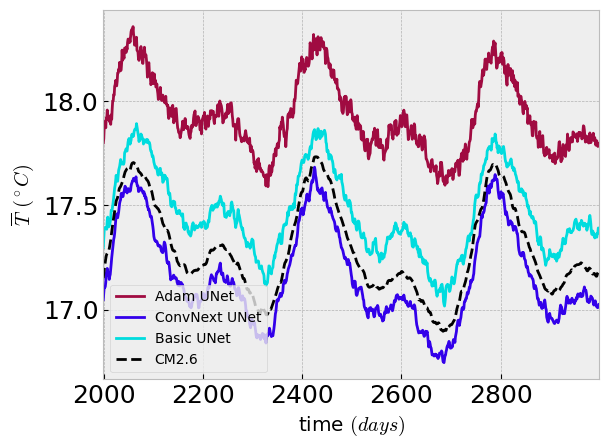

In [101]:
N_eval = 3000
print("Getting Mean stats...")
mean_T_net, mean_T_true = compute_mean_single(
    N_eval,
    T_test,
    model_pred_net[:, :, :, 2],
    eval.area,
    eval.wet_bool,
)
mean_T_saved = []
for model_pred_saved in model_pred_saved_nets:
    mean_T_i, mean_T_true = compute_mean_single(
        N_eval,
        T_test,
        model_pred_saved[:, :, :, 2],
        eval.area,
        eval.wet_bool,
    )
    mean_T_saved.append(mean_T_i)

print("Plotting Mean...")
plot_metrics_mean(
    eval.pred_names + [eval.network],
    eval.region,
    eval.str_save,
    eval.output_dir,
    mean_T_true,
    mean_T_saved + [mean_T_net],
    eval.JUPYTER_MODE
)

In [82]:

def plot_map(
    network_names,
    region,
    save_str,
    output_dir,
    grids,
    Nb,
    wet_nan,
    long_KE_true,
    long_KEs,
    mode="KE",
    JUPYTER_MODE=False,
):

    plt.style.use("bmh")

    # Long KE
    plt.rcParams.update({"font.size": 12})
    if len(long_KEs) > 1:
        fig, axs = plt.subplots(
            2,
            3,
            figsize=(12, 5),
            gridspec_kw={
                "width_ratios": [1, 1, 1],
                "height_ratios": [1, 1],
                "wspace": 0.25,
                "hspace": 0.5,
            },
            subplot_kw={"projection": ccrs.PlateCarree()},
        )
    elif len(long_KEs) == 1:
        fig, axs = plt.subplots(
            2,
            2,
            figsize=(12, 5),
            gridspec_kw={
                "width_ratios": [1, 1],
                "height_ratios": [1, 1],
                "wspace": 0.25,
                "hspace": 0.5,
            },
            subplot_kw={"projection": ccrs.PlateCarree()},
        )
    else:
        print("0 entries in long_KE")
        return

    if mode == "KE":
        vmin = 0
        vmax = 45
    elif mode == "TEMP":
        vmin = -5
        vmax = 30

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    cmap = cmocean.cm.thermal  # cmocean.cm.diff

    # Ground Truth
    if "global" in region:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true * wet_nan,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
    else:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )

    axs[0, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    gl = axs[0, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    axs[0, 0].set_title(r"CM2.6", size=15)

    pos = axs[1, 0].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.075,
        pos.y0 + 0.15,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"KE $( J/m^2 )$", fontsize=20)

    if mode == "KE":
        cbar.set_label(r"KE $( J/m^2 )$", fontsize=20)
    elif mode == "TEMP":
        cbar.set_label(r"$\overline{T}$ $( ^\circ C )$", fontsize=20)

    fig.delaxes(cax)

    for i, long_KE_i in enumerate(long_KEs):
        if long_KE_i is not None:
            if i == 0:
                idy, idx = 0, 1
            elif i == 1:
                idy, idx = 0, 2
            elif i == 2:
                idy, idx = 1, 1
            elif i == 3:
                idy, idx = 1, 2

            if "global" in region:
                axs[idy, idx].pcolormesh(
                    x_plot,
                    y_plot,
                    long_KE_i * wet_nan,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )
            else:
                axs[idy, idx].pcolormesh(
                    x_plot,
                    y_plot,
                    long_KE_i[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )

            axs[idy, idx].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            gl = axs[idy, idx].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=True,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            axs[idy, idx].set_title(network_names[i], size=15)

    axs[1, 0].set_axis_off()
    if len(long_KEs) == 1:
        axs[1, 1].set_axis_off()
    if len(long_KEs) == 2:
        axs[1, 1].set_axis_off()
        axs[1, 2].set_axis_off()
    if len(long_KEs) == 3:
        axs[1, 2].set_axis_off()
    

    region_title = ""

    for i in region:
        if region == "Quiescent_Ext":
            region_title = "South Pacific"
        elif region == "Africa_Ext":
            region_title = "African Cape"
        elif i == "_":
            region_title += " "
        elif i == "E":
            break
        else:
            region_title += i
    region_title = str(region_title)

    # a = fig.suptitle(
    #     r"Mean KE " + region_title + ": $t = " + str(1000) + "$ days ",
    #     fontsize=16,
    # )

    if JUPYTER_MODE:
        plt.show()
    else:
        plt.savefig(
            Path(output_dir) / ("Mean_" + mode + region + "_" + save_str + ".png"),
            bbox_inches="tight",
        )
        plt.clf()


def plot_error_map(
    network_names,
    region,
    save_str,
    output_dir,
    grids,
    Nb,
    wet_nan,
    long_KE_true,
    long_mse_KEs,
    mode="KE",
    JUPYTER_MODE=False,
):

    plt.style.use("bmh")

    # Long KE
    plt.rcParams.update({"font.size": 12})
    if len(long_mse_KEs) > 1:
        fig, axs = plt.subplots(
            2,
            3,
            figsize=(12, 5),
            gridspec_kw={
                "width_ratios": [1, 1, 1],
                "height_ratios": [1, 1],
                "wspace": 0.25,
                "hspace": 0.5,
            },
            subplot_kw={"projection": ccrs.PlateCarree()},
        )
    elif len(long_mse_KEs) == 1:
        fig, axs = plt.subplots(
            2,
            2,
            figsize=(12, 5),
            gridspec_kw={
                "width_ratios": [1, 1],
                "height_ratios": [1, 1],
                "wspace": 0.25,
                "hspace": 0.5,
            },
            subplot_kw={"projection": ccrs.PlateCarree()},
        )
    else:
        print("0 entries in long_KE")
        return

    if mode == "KE":
        vmin = 0
        vmax = 200
    elif mode == "TEMP":
        vmin = 0
        vmax = 4

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    cmap = cmocean.cm.thermal  # cmocean.cm.diff

    # Ground Truth
    if "global" in region:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true * wet_nan,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
    else:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )

    axs[0, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    gl = axs[0, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    axs[0, 0].set_title(r"CM2.6", size=15)

    pos = axs[1, 0].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.075,
        pos.y0 + 0.15,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    if mode == "KE":
        cbar.set_label(r"RMSE KE $( J/m^2 )$", fontsize=20)
    elif mode == "TEMP":
        cbar.set_label(r"RMSE $\overline{T}$ $( ^\circ C )$", fontsize=20)

    fig.delaxes(cax)

    for i, long_mse_KE_i in enumerate(long_mse_KEs):
        if long_mse_KE_i is not None:
            if i == 0:
                idy, idx = 0, 1
            elif i == 1:
                idy, idx = 0, 2
            elif i == 2:
                idy, idx = 1, 1
            elif i == 3:
                idy, idx = 1, 2

            if "global" in region:
                axs[idy, idx].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_KE_i * wet_nan,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )
            else:
                axs[idy, idx].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_KE_i[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )

            axs[idy, idx].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            gl = axs[idy, idx].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=True,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            axs[idy, idx].set_title(network_names[i], size=15)

    axs[1, 0].set_axis_off()
    if len(long_mse_KEs) == 1:
        axs[1, 1].set_axis_off()
    if len(long_mse_KEs) == 2:
        axs[1, 1].set_axis_off()
        axs[1, 2].set_axis_off()
    if len(long_mse_KEs) == 3:
        axs[1, 2].set_axis_off()
    

    region_title = ""

    for i in region:
        if region == "Quiescent_Ext":
            region_title = "South Pacific"
        elif region == "Africa_Ext":
            region_title = "African Cape"
        elif i == "_":
            region_title += " "
        elif i == "E":
            break
        else:
            region_title += i
    region_title = str(region_title)

    # a = fig.suptitle(
    #     r"Mean KE " + region_title + ": $t = " + str(1000) + "$ days ",
    #     fontsize=16,
    # )

    if JUPYTER_MODE:
        plt.show()
    else:
        plt.savefig(
            Path(output_dir) / ("MSE_" + mode + region + "_" + save_str + ".png"),
            bbox_inches="tight",
        )
        plt.clf()



In [89]:
def gen_value_range(start, N_eval, test_data, model_pred, index):
    data_out_cpu = np.array(test_data[:][1].cpu()) * np.expand_dims(
        test_data.norm_vals["s_out"], [0, 2, 3]
    ) + np.expand_dims(test_data.norm_vals["m_out"], [0, 2, 3])
    pred_temp = model_pred[start : start + N_eval, :, :, index]
    true_temp = data_out_cpu[start : start + N_eval, index]
    return pred_temp, true_temp

Plotting Long mean temp...


/state/partition1/job-46339814/ipykernel_1611792/2320356.py:116: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)


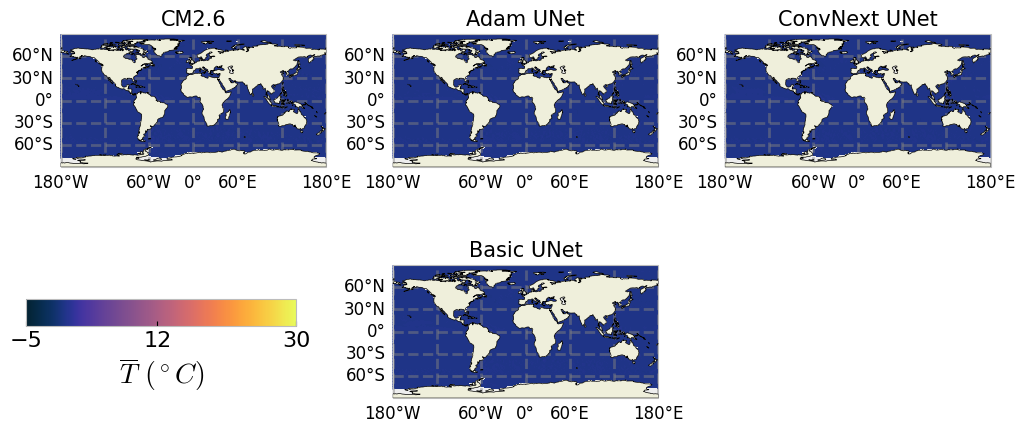

Plotting Long MSE temp


/state/partition1/job-46339814/ipykernel_1611792/2320356.py:335: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)


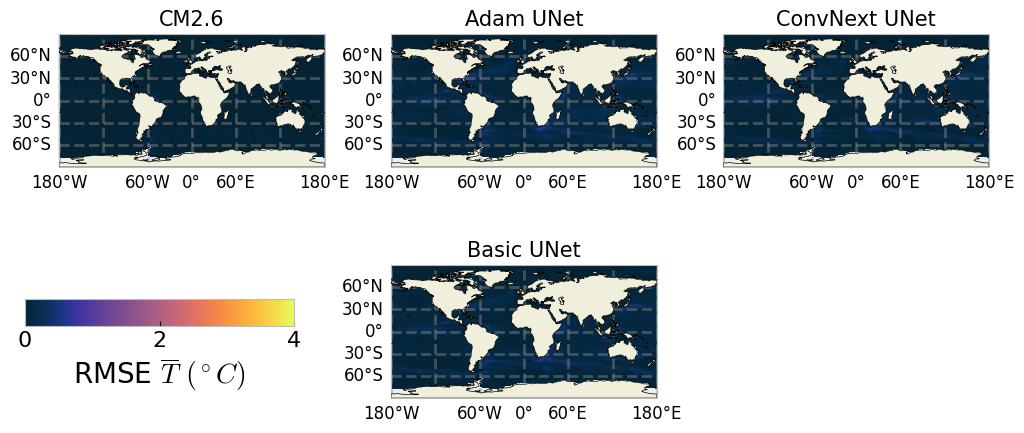

In [91]:
start = 1999
N_plot = 2999

long_temp_net, long_temp_true = gen_value_range(
    start, N_plot, eval.test_data, model_pred_net, 2
)
long_temp_net = long_temp_net.mean(0)

long_temp_saved = []
for model_pred_saved in model_pred_saved_nets:
    long_temp_savedi, _ = gen_value_range(
        start, N_plot, eval.test_data, model_pred_saved, 2
    )
    long_temp_savedi = long_temp_savedi.mean(0)
    long_temp_saved.append(long_temp_savedi)

long_temp_true = long_temp_true.mean(0)

print("Plotting Long mean temp...")
plot_map(
    eval.pred_names + [eval.network],
    eval.region + "_Long_",
    eval.str_save,
    eval.output_dir,
    eval.grids,
    eval.Nb,
    eval.wet_nan,
    long_temp_true,
    long_temp_saved + [long_temp_net],
    "TEMP",
    eval.JUPYTER_MODE
)


start = 0
N_plot = 2999

long_temp_net, long_temp_true = gen_value_range(
    start, N_plot, eval.test_data, model_pred_net, 2
)
mse_temp_net = np.sqrt(((long_temp_net - long_temp_true)**2).mean(axis=0))
long_temp_net = long_temp_net.mean(0)

long_temp_RMSE_saved = []
for model_pred_saved in model_pred_saved_nets:
    long_temp_savedi, _ = gen_value_range(
        start, N_plot, eval.test_data, model_pred_saved, 2
    )
    mse_KE_savedi = np.sqrt(((long_temp_savedi - long_temp_true)**2).mean(axis=0))
    long_temp_RMSE_saved.append(mse_KE_savedi)

long_temp_true = long_temp_true.mean(0)


print("Plotting Long MSE temp")
plot_error_map(
    eval.pred_names + [eval.network],
    eval.region + "_Long_",
    eval.str_save,
    eval.output_dir,
    eval.grids,
    eval.Nb,
    eval.wet_nan,
    long_temp_true,
    long_temp_RMSE_saved + [mse_temp_net],
    "TEMP",
    eval.JUPYTER_MODE
)

In [87]:
start = 0
N_plot = 2999

long_temp_net, long_temp_true = gen_temp_range(
    start, N_plot, eval.test_data, model_pred_net
)


In [64]:
print("Plot Long metrics begin...")
model_pred_net = (
    xr.open_zarr(
        eval.pred_model_path
        / (
            "Pred_lateral_Fast_Data_025_"
            + eval.post_pred_name
            + "_rand_seed_"
            + str(1)
            + ".zarr"
        )
    )
    .to_array()
    .to_numpy()
    .squeeze()
)

model_pred_saved_nets = []
for model_pred_path in eval.pred_paths:
    net_path = Path(model_pred_path) / (
        "Pred_lateral_Fast_Data_025_"
        + eval.pred_region
        + "_in_"
        + eval.str_in
        + "ext_"
        + "tau_u_tau_v_t_ref_"
        + "N_samples_"
        + str(4000)
        + "_rand_seed_"
        + str(1)
        + ".zarr"
    )

    model_pred_saved_nets.append(
        xr.open_zarr(net_path).to_array().to_numpy().squeeze()
    )

Plot Long metrics begin...


In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import cartopy as cart
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

def plot_time_spec(
    network_names,
    axs,
    plt_index,
    index,
    N_test,
    freqs,
    auto_FFT,
    FFTs,
    clist,
    legend=True,
):
    T_plot = 200

    N_int = int(T_plot)
    N_true = min(N_test, N_int)

    var_list = {
        "1": r"$\widehat{\overline{v}}$ $( m/s )$",
        "0": r"$\widehat{\overline{u}}$ $( m/s )$",
        "2": r"$\widehat{\overline{T}}$ $( ^\circ C )$",
    }

    axs[plt_index].semilogx(
        freqs[:N_int], auto_FFT[:N_int, index], "--k", label="CM2.6", zorder=5
    )

    for i, FFT_i in enumerate(FFTs):
        if FFT_i is not None:
            axs[plt_index].plot(
                freqs[:N_int],
                FFT_i.mean(axis=0)[:N_int, index],
                color=clist[i],
                label=network_names[i],
            )
            axs[plt_index].fill_between(
                freqs[:N_int],
                FFT_i.mean(axis=0)[:N_int, index] - FFT_i.std(axis=0)[:N_int, index],
                FFT_i.mean(axis=0)[:N_int, index] + FFT_i.std(axis=0)[:N_int, index],
                ls="--",
                color=clist[i],
                alpha=0.25,
            )

    axs[plt_index].set_ylabel(r"" + var_list[str(index)])
    axs[plt_index].set_xlabel(r"Frequency $( 1/day )$")

    axs[plt_index].set_xlim([0, freqs[T_plot]])
    axs[plt_index].set_ylim([0, auto_FFT[1:N_int, index].max() * 2])

    if legend:
        axs[plt_index].legend(ncol=1, loc="upper right")


def plot_var(
    network_names,
    axs,
    plt_index,
    index,
    N_test,
    lag,
    auto_var,
    vars,
    clist,
):
    T_plot = 1098

    N_int = int(T_plot / lag)
    N_true = min(N_test, N_int)

    var_list = {
        "1": r"$\mathrm{Var}(\overline{v})$",
        "0": r"$\mathrm{Var}(\overline{u})$",
        "2": r"$\mathrm{Var}(\overline{T})$",
    }

    axs[plt_index].plot(
        (np.arange(N_int) * lag) / 366,
        auto_var[:N_int, index],
        "--k",
        label="CM2.6",
        zorder=5,
    )

    for i, vars_i in enumerate(vars):
        if vars_i is not None:
            axs[plt_index].plot(
                (np.arange(N_int) * lag) / 366,
                vars_i.mean(axis=0)[:N_int, index],
                color=clist[i],
                label=network_names[i],
            )
            axs[plt_index].fill_between(
                (np.arange(N_int) * lag) / 366,
                vars_i.mean(axis=0)[:N_int, index] - vars_i.std(axis=0)[:N_int, index],
                vars_i.mean(axis=0)[:N_int, index] + vars_i.std(axis=0)[:N_int, index],
                ls="--",
                color=clist[i],
                alpha=0.25,
            )

    axs[plt_index].set_ylabel(r"" + var_list[str(index)])
    axs[plt_index].set_xlabel(r"Time $( years )$")

    axs[plt_index].set_xlim([0, T_plot / 366])
    axs[plt_index].yaxis.set_major_formatter(
        ticker.ScalarFormatter(useMathText=True, useOffset=False)
    )
    axs[plt_index].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    axs[plt_index].xaxis.set_major_locator(
        ticker.MultipleLocator(base=0.5)
    )  # Adjust base as needed


def plot_mean(
    network_names,
    axs,
    plt_index,
    index,
    N_test,
    lag,
    auto_mean,
    means,
    clist,
):

    T_plot = N_test

    N_int = int(T_plot / lag)
    N_true = min(N_test, N_int)

    var_list = {
        "1": r"$\overline{v}$ $( m/s )$",
        "0": r"$\overline{u}$ $( m/s )$",
        "2": r"$\overline{T}$ $( ^\circ C )$",
    }

    axs[plt_index].plot(
        (np.arange(N_int) * lag) / 366,
        auto_mean[:N_int, index],
        "--k",
        label="CM2.6",
        zorder=5,
    )

    for i, means_i in enumerate(means):
        if means_i is not None:
            axs[plt_index].plot(
                (np.arange(N_int) * lag) / 366,
                means_i.mean(axis=0)[:N_int, index],
                color=clist[i],
                label=network_names[i],
            )
            axs[plt_index].fill_between(
                (np.arange(N_int) * lag) / 366,
                means_i.mean(axis=0)[:N_int, index]
                - means_i.std(axis=0)[:N_int, index],
                means_i.mean(axis=0)[:N_int, index]
                + means_i.std(axis=0)[:N_int, index],
                ls="--",
                color=clist[i],
                alpha=0.25,
            )

    axs[plt_index].set_ylabel(r"" + var_list[str(index)])
    axs[plt_index].set_xlabel(r"Time $( years )$")

    min_val = auto_mean[:N_int, index].min()
    max_val = auto_mean[:N_int, index].max()

    if min_val > 0:
        axs[plt_index].set_ylim([min_val * 0.8, max_val * 1.1])
    elif min_val < 0 and max_val > 0:
        axs[plt_index].set_ylim([min_val * 1.1, max_val * 1.1])
    else:
        axs[plt_index].set_ylim([min_val * 1.1, 0])

    if index == 2:
        axs[plt_index].set_xlim([4, 8])
        axs[plt_index].xaxis.set_major_locator(
            ticker.MultipleLocator(base=1)
        )  # Adjust base as needed

    #     axs[plt_index].set_ylim([22,28])
    else:
        axs[plt_index].set_xlim([7, 8])
        axs[plt_index].yaxis.set_major_formatter(
            ticker.ScalarFormatter(useMathText=True, useOffset=False)
        )
        axs[plt_index].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
        axs[plt_index].xaxis.set_major_locator(
            ticker.MultipleLocator(base=0.5)
        )  # Adjust base as needed


def plot_acc(
    network_names,
    axs,
    plt_ind_acc,
    index,
    N_test,
    lag,
    auto_ACC,
    ACCs,
    clist,
    legend=False,
):
    T_plot = 100

    N_int = int(T_plot / lag)
    N_true = min(N_test, N_int)

    var_list = {
        "1": r"$\overline{v}$ $( m/s )$",
        "0": r"$\overline{u}$ $( m/s )$",
        "2": r"$\overline{T}$ $( ^\circ C )$",
    }

    axs[plt_ind_acc].plot(
        (np.arange(N_int) * lag),
        auto_ACC.mean(axis=0)[:N_int, index],
        color="dimgrey",
        label="$\mathbf{\Phi}(t=0)$",
    )
    # axs[plt_ind_acc].fill_between(
    #     (np.arange(N_int) * lag),
    #     auto_ACC.mean(axis=0)[:N_int, index] - auto_ACC.std(axis=0)[:N_int, index],
    #     auto_ACC.mean(axis=0)[:N_int, index] + auto_ACC.std(axis=0)[:N_int, index],
    #     ls="-",
    #     color="dimgrey",
    #     alpha=0.2,
    # )

    for i, ACC_i in enumerate(ACCs):
        if ACC_i is not None:
            axs[plt_ind_acc].plot(
                (np.arange(N_int) * lag),
                ACC_i.mean(axis=0)[:N_int, index],
                color=clist[i],
                label=network_names[i],
            )
            # axs[plt_ind_acc].fill_between(
            #     (np.arange(N_int) * lag),
            #     ACC_i.mean(axis=0)[:N_int, index] - ACC_i.std(axis=0)[:N_int, index],
            #     ACC_i.mean(axis=0)[:N_int, index] + ACC_i.std(axis=0)[:N_int, index],
            #     ls="-",
            #     color=clist[i],
            #     alpha=0.2,
            # )

    axs[plt_ind_acc].set_ylabel(r"ACC " + var_list[str(index)])

    axs[plt_ind_acc].set_xlabel("Time (days)")

    axs[plt_ind_acc].set_ylim([0, 1])
    axs[plt_ind_acc].set_xlim([0, T_plot])
    if legend:
        axs[plt_ind_acc].legend(ncol=2)


def plot_corr(
    network_names,
    axs,
    plt_ind_acc,
    index,
    N_test,
    lag,
    auto_corrs,
    corrs,
    clist,
):

    T_plot = 100

    N_int = int(T_plot / lag)
    N_true = min(N_test, N_int)

    var_list = {
        "1": r"$\overline{v}$ $( m/s )$",
        "0": r"$\overline{u}$ $( m/s )$",
        "2": r"$\overline{T}$ $( ^\circ C )$",
    }

    axs[plt_ind_acc].plot(
        (np.arange(N_int) * lag),
        auto_corrs.mean(axis=0)[:N_int, index],
        color="dimgrey",
        label="$\mathbf{\Phi}(t=0)$",
    )
    axs[plt_ind_acc].fill_between(
        (np.arange(N_int) * lag),
        auto_corrs.mean(axis=0)[:N_int, index] - auto_corrs.std(axis=0)[:N_int, index],
        auto_corrs.mean(axis=0)[:N_int, index] + auto_corrs.std(axis=0)[:N_int, index],
        ls="-",
        color="dimgrey",
        alpha=0.2,
    )

    for i, corrs_i in enumerate(corrs):
        if corrs_i is not None:
            axs[plt_ind_acc].plot(
                (np.arange(N_int) * lag),
                corrs_i.mean(axis=0)[:N_int, index],
                color=clist[i],
                label=network_names[i],
            )
            axs[plt_ind_acc].fill_between(
                (np.arange(N_int) * lag),
                corrs_i.mean(axis=0)[:N_int, index]
                - corrs_i.std(axis=0)[:N_int, index],
                corrs_i.mean(axis=0)[:N_int, index]
                + corrs_i.std(axis=0)[:N_int, index],
                ls="-",
                color=clist[i],
                alpha=0.2,
            )

    axs[plt_ind_acc].set_ylabel(r"Correlation " + var_list[str(index)])
    axs[plt_ind_acc].set_xlabel(r"Time $( days )$")

    axs[plt_ind_acc].set_ylim([0, 1])
    axs[plt_ind_acc].set_xlim([0, T_plot])


def plot_KE(
    network_names,
    axs,
    plt_ind_acc,
    N_test,
    lag,
    auto_KE,
    KEs,
    clist,
):

    T_plot = 200

    N_int = int(T_plot / lag)
    N_true = min(N_test, N_int)

    var_list = {
        "1": r"$\overline{v}$ $( m/s )$",
        "0": r"$\overline{u}$ $( m/s )$",
        "2": r"$\overline{T}$ $( ^\circ C )$",
    }

    axs[plt_ind_acc].plot(
        (np.arange(N_int) * lag) / 366,
        auto_KE[:N_int].mean(axis=0),
        color="dimgrey",
        label="$\mathbf{\Phi}(t=0)$",
    )
    axs[plt_ind_acc].fill_between(
        (np.arange(N_int) * lag) / 366,
        auto_KE.mean(axis=0)[:N_int] - auto_KE.std(axis=0)[:N_int],
        auto_KE.mean(axis=0)[:N_int] + auto_KE.std(axis=0)[:N_int],
        ls="-",
        color="dimgrey",
        alpha=0.2,
    )

    for i, KE_i in enumerate(KEs):
        if KE_i is not None:
            axs[plt_ind_acc].plot(
                (np.arange(N_int) * lag) / 366,
                KE_i.mean(axis=0)[:N_int],
                color=clist[i],
                label=network_names[i],
            )
            axs[plt_ind_acc].fill_between(
                (np.arange(N_int) * lag) / 366,
                KE_i.mean(axis=0)[:N_int] - KE_i.std(axis=0)[:N_int],
                KE_i.mean(axis=0)[:N_int] + KE_i.std(axis=0)[:N_int],
                ls="-",
                color=clist[i],
                alpha=0.2,
            )

    axs[plt_ind_acc].set_ylabel(r"KE")
    axs[plt_ind_acc].set_xlabel(r"Time $( days )$")

    axs[plt_ind_acc].set_ylim([0, 0.05])


def plot_rmse(
    network_names,
    axs,
    plt_ind_acc,
    index,
    N_test,
    lag,
    auto_rmse,
    rmses,
    clist,
    legend=False,
):
    T_plot = 200

    N_int = int(T_plot / lag)
    N_true = min(N_test, N_int)

    var_list = {
        "1": r"$\overline{v}$ $( m/s )$",
        "0": r"$\overline{u}$ $( m/s )$",
        "2": r"$\overline{T}$ $( ^\circ C )$",
    }

    axs[plt_ind_acc].plot(
        (np.arange(N_int) * lag),
        auto_rmse.mean(axis=0)[:N_int, index],
        color="dimgrey",
        label="$\mathbf{\Phi}(t=0)$",
    )
    # axs[plt_ind_acc].fill_between(
    #     (np.arange(N_int) * lag),
    #     auto_rmse.mean(axis=0)[:N_int, index] - auto_rmse.std(axis=0)[:N_int, index],
    #     auto_rmse.mean(axis=0)[:N_int, index] + auto_rmse.std(axis=0)[:N_int, index],
    #     ls="-",
    #     color="dimgrey",
    #     alpha=0.2,
    # )

    for i, rmse_i in enumerate(rmses):
        if rmse_i is not None:
            axs[plt_ind_acc].plot(
                (np.arange(N_int) * lag),
                rmse_i.mean(axis=0)[:N_int, index],
                color=clist[i],
                label=network_names[i],
            )
            # axs[plt_ind_acc].fill_between(
            #     (np.arange(N_int) * lag),
            #     rmse_i.mean(axis=0)[:N_int, index] - rmse_i.std(axis=0)[:N_int, index],
            #     rmse_i.mean(axis=0)[:N_int, index] + rmse_i.std(axis=0)[:N_int, index],
            #     ls="-",
            #     color=clist[i],
            #     alpha=0.2,
            # )

    axs[plt_ind_acc].set_ylabel(r"RMSE " + var_list[str(index)])
    axs[plt_ind_acc].set_xlabel(r"Time $( days )$")

    axs[plt_ind_acc].set_xlim([0, T_plot])
    if legend:
        axs[plt_ind_acc].legend(ncol=2)
    if index == 2:
        axs[plt_ind_acc].set_ylim([0, 8])

    if index == 1 or index == 0:
        axs[plt_ind_acc].yaxis.set_major_formatter(
            ticker.ScalarFormatter(useMathText=True, useOffset=False)
        )
        axs[plt_ind_acc].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))


def plot_long_time_stats(
    network_names,
    region,
    save_str,
    output_dir,
    N_test,
    lag,
    freqs,
    auto_FFT,
    FFTs,
    auto_mean,
    means,
    JUPYTER_MODE=False,
):

    plt.clf()
    plt.style.use("bmh")

    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]

    # plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
    plt.rc("axes", titlesize=20)  # fontsize of the axes title
    plt.rc("axes", labelsize=18)  # fontsize of the x and y labels
    plt.rc("xtick", labelsize=18)  # fontsize of the tick labels
    plt.rc("ytick", labelsize=18)  # fontsize of the tick labels
    plt.rc("legend", fontsize=10)  # legend fontsize
    plt.rc("figure", titlesize=18)

    fig, axs = plt.subplots(
        2,
        2,
        figsize=(11, 6),
        gridspec_kw={
            "width_ratios": [1, 1],
            "height_ratios": [1, 1],
            "wspace": 0.3,
            "hspace": 0.5,
        },
    )
    plot_time_spec(
        network_names,
        axs,
        (0, 0),
        0,
        N_test,
        freqs,
        auto_FFT,
        FFTs,
        clist,
        False,
    )
    plot_mean(
        network_names,
        axs,
        (0, 1),
        0,
        N_test,
        lag,
        auto_mean,
        means,
        clist,
    )
    plot_time_spec(
        network_names,
        axs,
        (1, 0),
        1,
        N_test,
        freqs,
        auto_FFT,
        FFTs,
        clist,
    )
    plot_mean(
        network_names,
        axs,
        (1, 1),
        2,
        N_test,
        lag,
        auto_mean,
        means,
        clist,
    )

    region_title = ""

    for i in region:
        if region == "Quiescent_Ext":
            region_title = "South Pacific"
        elif region == "Africa_Ext":
            region_title = "African Cape"
        elif i == "_":
            region_title += " "
        elif i == "E":
            break
        else:
            region_title += i
    region_title = str(region_title)

    # fig.suptitle("Long-Time Statistics " + region_title, fontsize=16)

    if JUPYTER_MODE:
        plt.show()
    
    else:
        plt.savefig(
            Path(output_dir)
            / ("Long_Time_Comp_Boundary_" + region + "_" + save_str + ".png"),
            bbox_inches="tight",
        )
        plt.clf()

In [35]:
def get_stats(
    zarr_path,
    region,
    rand_int,
    str_in,
    str_ext,
    test_data,
    area,
    wet_bool,
    N_mean,
    lag,
):
    try:
        model_pred_atm = (
            xr.open_zarr(
                Path(zarr_path)
                / (
                    "Pred_lateral_Fast_Data_025_"
                    + region
                    + "_in_"
                    + str_in
                    + "ext_"
                    + str_ext
                    + "N_samples_"
                    + str(4000)
                    + "_rand_seed_"
                    + str(rand_int)
                    + ".zarr"
                )
            )
            .sel(time=slice(0, N_mean))
            .to_array()
            .to_numpy()
            .squeeze()
        )
    except Exception as error:
        print(error)
        print(zarr_path)
        print(region, str_in, str_ext, rand_int)
        # raise Exception(
        #     f"Path in {zarr_path} does not exist. Make sure to set run_gen_pred to True in config."
        # )

    mean_atm, auto_mean = compute_mean(
        N_mean, test_data, model_pred_atm, area.cpu(), wet_bool
    )
    var_atm, auto_var = compute_var(
        N_mean, test_data, model_pred_atm, area.cpu(), wet_bool
    )
    rmse_atm, auto_rmse = compute_rmse(
        np.min((500, N_mean)), test_data, model_pred_atm, area.cpu(), wet_bool
    )
    corrs_atm, auto_corrs = compute_corrs(
        np.min((500, N_mean)), test_data, model_pred_atm, wet_bool
    )
    KE, auto_KE = compute_KE(N_mean, test_data, model_pred_atm, area, wet_bool)
    freqs, FFT, auto_FFT = compute_time_spec(N_mean, auto_mean, mean_atm, lag)

    return (
        model_pred_atm,
        mean_atm,
        auto_mean,
        rmse_atm,
        auto_rmse,
        corrs_atm,
        auto_corrs,
        KE,
        auto_KE,
        freqs,
        FFT,
        auto_FFT,
        var_atm,
        auto_var,
    )

def get_spred(
    zarr_path,
    region,
    num_IC,
    str_in,
    str_ext,
    test_data,
    area,
    wet_bool,
    N_mean,
    lag,
):
    mean = np.zeros((num_IC, N_mean, 3))
    var = np.zeros((num_IC, N_mean, 3))
    KE = np.zeros((num_IC, N_mean))
    rmse = np.zeros((num_IC, np.min((500, N_mean)), 3))
    corrs = np.zeros((num_IC, np.min((500, N_mean)), 3))
    FFTs = np.zeros((num_IC, int(N_mean / 2 + 1), 3))

    for i in range(0, num_IC):
        (
            out,
            mean_1,
            out,
            rmse_1,
            out,
            corrs_1,
            out,
            KE_1,
            out,
            freqs,
            FFT_1,
            out,
            var_1,
            out,
        ) = get_stats(
            zarr_path,
            region,
            i + 1,
            str_in,
            str_ext,
            test_data,
            area,
            wet_bool,
            N_mean,
            lag,
        )
        KE[i] = KE_1
        mean[i] = mean_1
        rmse[i] = rmse_1
        corrs[i] = corrs_1
        FFTs[i] = FFT_1
        var[i] = var_1
    return mean, rmse, corrs, KE, FFTs, freqs, var

print("Long time stats compute begin...")
mean_net, rmse_net, corrs_net, KE_net, FFTs_net, freqs, var_net = get_spred(
    eval.pred_model_path,
    eval.region,
    3,
    eval.str_in,
    eval.str_ext,
    eval.test_data,
    eval.area,
    eval.wet_bool,
    eval.N_test,
    eval.lag,
)
(
    model_pred_net,
    m_net,
    auto_mean,
    r_net,
    auto_rmse,
    c_net,
    auto_corrs,
    K_net,
    auto_KE,
    freqs,
    F_net,
    auto_FFT,
    v_net,
    auto_var,
) = get_stats(
    eval.pred_model_path,
    eval.region,
    1,
    eval.str_in,
    eval.str_ext,
    eval.test_data,
    eval.area,
    eval.wet_bool,
    eval.N_test,
    eval.lag,
)  # zarr_path, region, rand_int, str_in, str_ext, test_data, area, wet_bool, N_mean, lag

# model_pred_saved_nets = []
FFTs_saved = []
means_saved = []
for model_pred_path in eval.pred_paths:
    mean_i, _, _, _, FFTs_i, freqs, _ = get_spred(
        model_pred_path,
        eval.pred_region,
        3,
        eval.str_in,
        eval.str_ext,
        eval.test_data,
        eval.area,
        eval.wet_bool,
        eval.N_test,
        eval.lag,
    )
    FFTs_saved.append(FFTs_i)
    means_saved.append(mean_i)

Long time stats compute begin...


/state/partition1/job-46339814/ipykernel_1611792/2516951723.py:57: UserWarning: Attempted to set non-positive left xlim on a log-scaled axis.
Invalid limit will be ignored.
  axs[plt_index].set_xlim([0, freqs[T_plot]])


<Figure size 640x480 with 0 Axes>

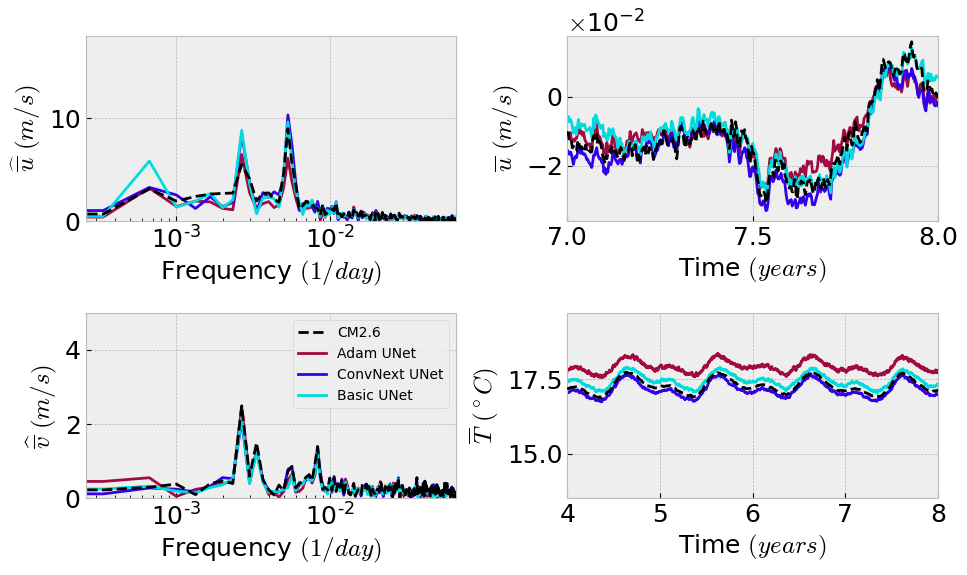

In [36]:
plot_long_time_stats(
            eval.pred_names + [eval.network],
            eval.region,
            eval.str_save,
            eval.output_dir,
            eval.N_test,
            eval.lag,
            freqs,
            auto_FFT,
            FFTs_saved + [FFTs_net],
            auto_mean,
            means_saved + [mean_net],
            eval.JUPYTER_MODE
        )

In [47]:


def plot_temp_mean(
    network_names,
    region,
    save_str,
    output_dir,
    N_test,
    lag,
    auto_mean,
    means,
    JUPYTER_MODE
    
):
    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]
    plt.style.use("bmh")

    T_plot = N_test

    N_int = int(T_plot / lag)
    N_true = min(N_test, N_int)

    plt.clf()
    plt.plot(
        (np.arange(N_int) * lag) / 366,
        auto_mean[:N_int, 2],
        "--k",
        label="CM2.6",
        zorder=5,
    )

    for i, means_i in enumerate(means):
        if means_i is not None:
            plt.plot(
                (np.arange(N_int) * lag) / 366,
                means_i.mean(axis=0)[:N_int, 2],
                color=clist[i],
                label=network_names[i],
            )
            plt.fill_between(
                (np.arange(N_int) * lag) / 366,
                means_i.mean(axis=0)[:N_int, 2]
                - means_i.std(axis=0)[:N_int, 2],
                means_i.mean(axis=0)[:N_int, 2]
                + means_i.std(axis=0)[:N_int, 2],
                ls="--",
                color=clist[i],
                alpha=0.25,
            )

    plt.set_ylabel(r"$\overline{T}$ $( ^\circ C )$")
    plt.set_xlabel(r"Time $( years )$")

    min_val = auto_mean[:N_int, 2].min()
    max_val = auto_mean[:N_int, 2].max()

    if min_val > 0:
        plt.set_ylim([min_val * 0.8, max_val * 1.1])
    elif min_val < 0 and max_val > 0:
        plt.set_ylim([min_val * 1.1, max_val * 1.1])
    else:
        plt.set_ylim([min_val * 1.1, 0])

    plt.set_xlim([4, 8])
    plt.xaxis.set_major_locator(
        ticker.MultipleLocator(base=1)
    )  # Adjust base as needed

#     plt.set_ylim([22,28])

    if JUPYTER_MODE:
        plt.show()
    
    else:
        plt.savefig(
            Path(output_dir)
            / ("Temperature_Time_Series_" + region + "_" + save_str + ".png"),
            bbox_inches="tight",
        )
        plt.clf()


AttributeError: module 'matplotlib.pyplot' has no attribute 'set_ylabel'

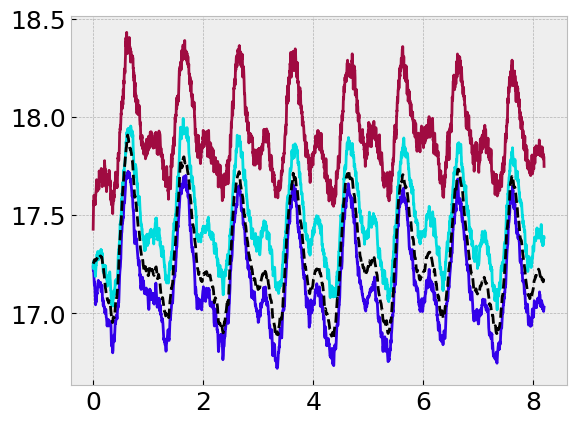

In [48]:
plot_temp_mean(
            eval.pred_names + [eval.network],
            eval.region,
            eval.str_save,
            eval.output_dir,
            eval.N_test,
            eval.lag,
            auto_mean,
            means_saved + [mean_net],
            eval.JUPYTER_MODE
        )

Plot metrics begin...
Getting PDF stats...
Plotting pdf...


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/plot_utils.py:945: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(


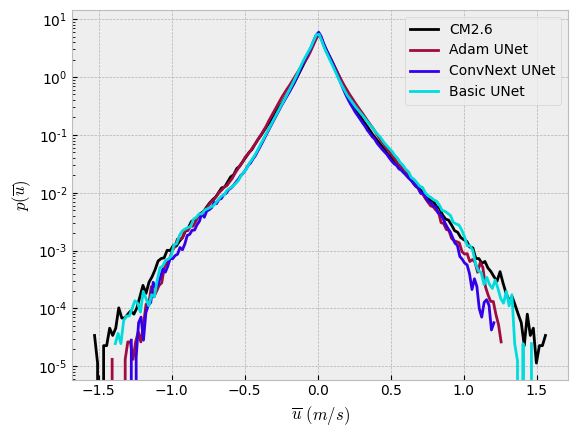

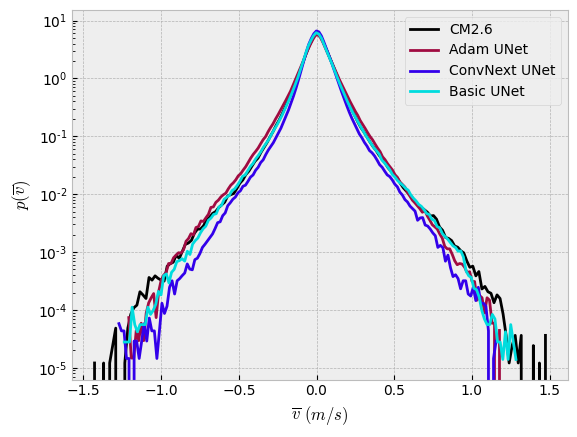

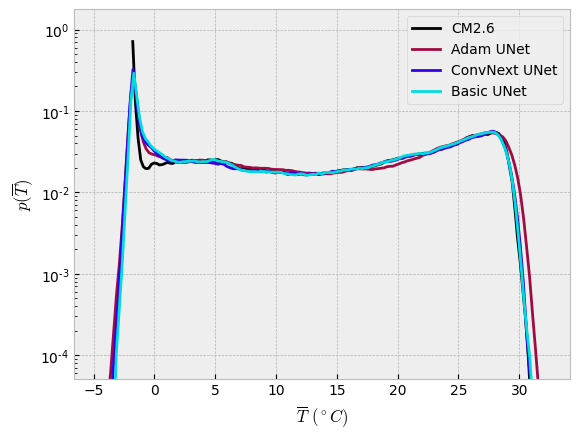

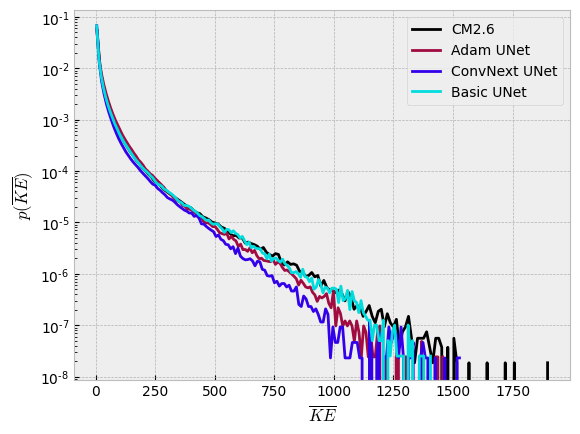

In [11]:
if cfg.run_plot_metrics:
    eval.plot_metrics()

#### Long Term Metrics

In [ ]:
if cfg.run_long_metrics:
    eval.plot_long_metrics()

#### Animations

In [43]:
if cfg.run_plot_animation:
    eval.plot_animation()

### Plot Functions